<a href="https://colab.research.google.com/github/HarshithReddy01/Algorithms-Practice/blob/master/Decision_Trees.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

In [2]:
iris = datasets.load_iris()
X = iris.data[:, [2, 3]]
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y)

In [3]:
X_combined = np.vstack((X_train, X_test))
y_combined = np.hstack((y_train, y_test))

In [4]:
def plot_decision_regions(X, y, classifier, test_idx=None, resolution=0.02):
    markers = ('o', 's', '^', 'v', '<')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    lab = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    lab = lab.reshape(xx1.shape)
    plt.contourf(xx1, xx2, lab, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1],
                    alpha=0.8, c=colors[idx],
                    marker=markers[idx],
                    label=f'Class {cl}',
                    edgecolor='black')
    if test_idx:
        X_test, y_test = X[test_idx, :], y[test_idx]
        plt.scatter(X_test[:, 0], X_test[:, 1],
                    c='none', edgecolor='black', alpha=1.0,
                    linewidth=1, marker='o', s=100, label='Test set')

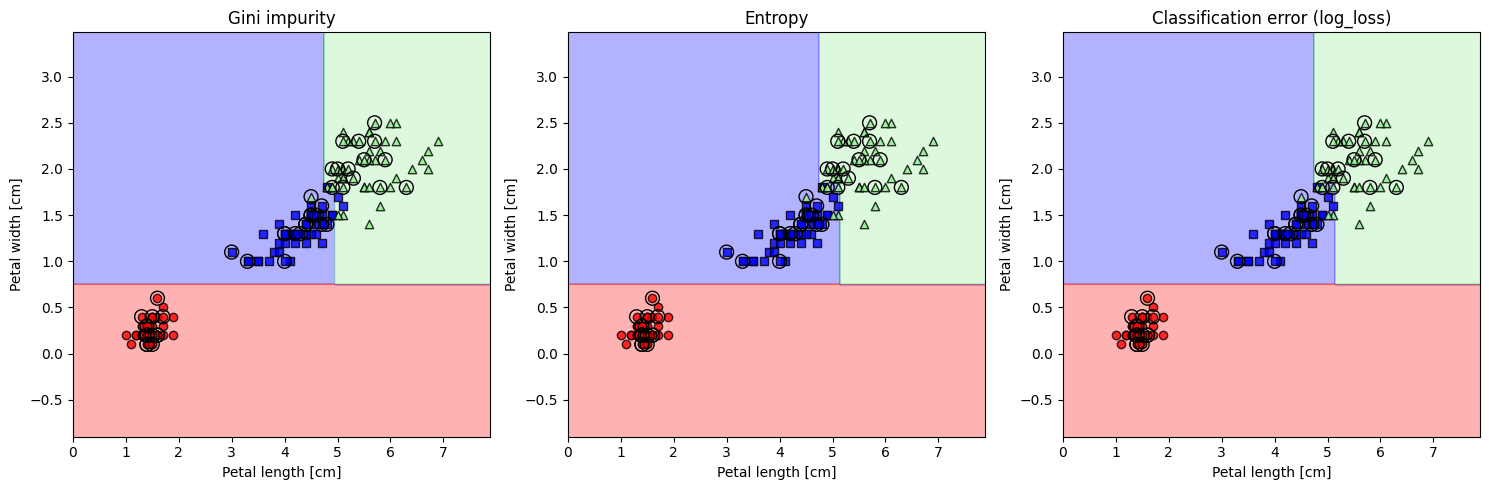

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

criteria = ['gini', 'entropy', 'log_loss']
titles   = ['Gini impurity', 'Entropy', 'Classification error (log_loss)']

for ax, criterion, title in zip(axes, criteria, titles):
    model = DecisionTreeClassifier(criterion=criterion,
                                   max_depth=4,
                                   random_state=1)
    model.fit(X_train, y_train)
    plt.sca(ax)
    plot_decision_regions(X_combined, y_combined,
                          classifier=model,
                          test_idx=range(105, 150))
    ax.set_title(title)
    ax.set_xlabel('Petal length [cm]')
    ax.set_ylabel('Petal width [cm]')

plt.tight_layout()
plt.show()

In [8]:
for criterion in ['gini', 'entropy', 'log_loss']:
    model = DecisionTreeClassifier(criterion=criterion,
                                   max_depth=4,
                                   random_state=1)
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    print(f'{criterion:12} → accuracy: {score:.3f}')

gini         → accuracy: 0.978
entropy      → accuracy: 0.933
log_loss     → accuracy: 0.933


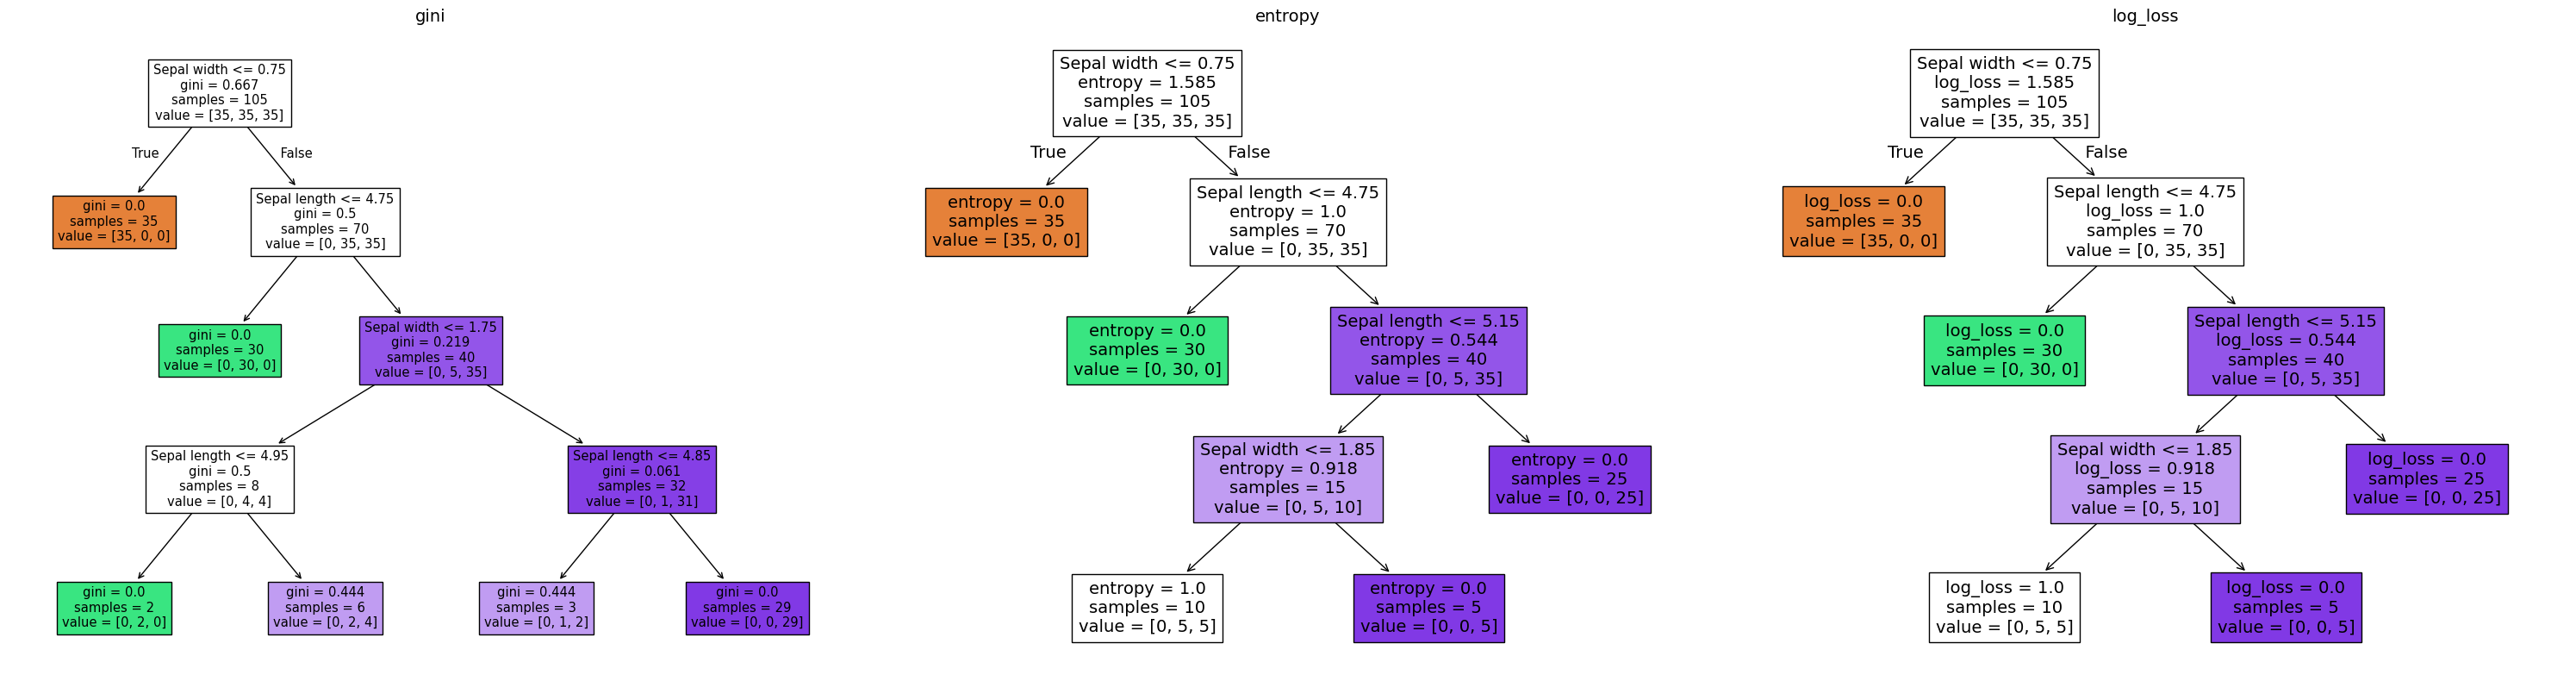

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(30, 8))

feature_names = ['Sepal length', 'Sepal width',
                 'Petal length', 'Petal width']

for ax, criterion in zip(axes, ['gini', 'entropy', 'log_loss']):
    model = DecisionTreeClassifier(criterion=criterion,
                                   max_depth=4,
                                   random_state=1)
    model.fit(X_train, y_train)
    tree.plot_tree(model,
                   feature_names=feature_names,
                   filled=True,
                   ax=ax)
    ax.set_title(criterion, fontsize=14)

plt.tight_layout()
plt.show()

In [10]:
from sklearn.ensemble import RandomForestClassifier

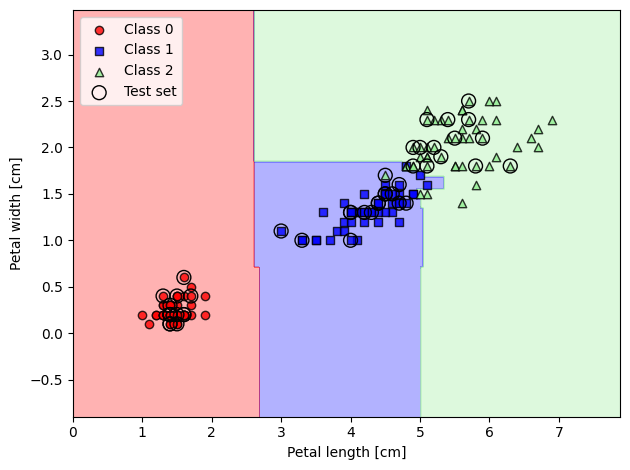

Random Forest accuracy: 0.978


In [11]:
forest = RandomForestClassifier(n_estimators=25,
                                random_state=1,
                                n_jobs=1)
forest.fit(X_train, y_train)

plot_decision_regions(X_combined, y_combined,
                      classifier=forest,
                      test_idx=range(105, 150))

plt.xlabel('Petal length [cm]')
plt.ylabel('Petal width [cm]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

print(f'Random Forest accuracy: {forest.score(X_test, y_test):.3f}')

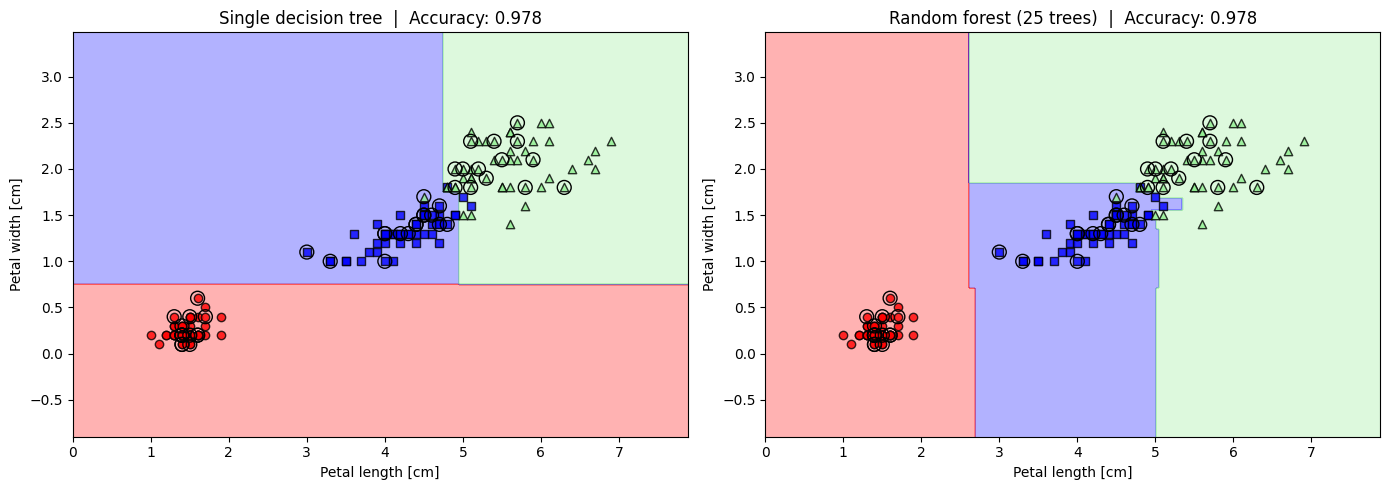

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = [
    DecisionTreeClassifier(max_depth=4, random_state=1),
    RandomForestClassifier(n_estimators=25, random_state=1, n_jobs=1)
]

titles = ['Single decision tree', 'Random forest (25 trees)']

for ax, model, title in zip(axes, models, titles):
    model.fit(X_train, y_train)
    plt.sca(ax)
    plot_decision_regions(X_combined, y_combined,
                          classifier=model,
                          test_idx=range(105, 150))
    score = model.score(X_test, y_test)
    ax.set_title(f'{title}  |  Accuracy: {score:.3f}')
    ax.set_xlabel('Petal length [cm]')
    ax.set_ylabel('Petal width [cm]')

plt.tight_layout()
plt.show()

   1 trees  →  accuracy: 0.933
   5 trees  →  accuracy: 0.978
  10 trees  →  accuracy: 0.978
  25 trees  →  accuracy: 0.978
  50 trees  →  accuracy: 0.978
 100 trees  →  accuracy: 0.978


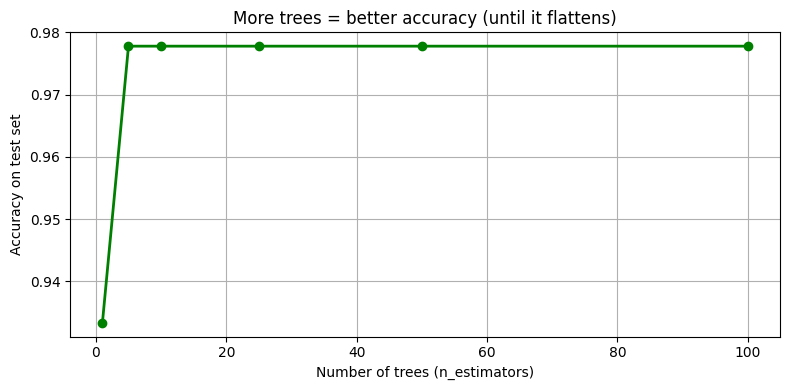

In [13]:
n_trees_list = [1, 5, 10, 25, 50, 100]
accuracies = []

for n in n_trees_list:
    forest = RandomForestClassifier(n_estimators=n,
                                    random_state=1,
                                    n_jobs=1)
    forest.fit(X_train, y_train)
    acc = forest.score(X_test, y_test)
    accuracies.append(acc)
    print(f'{n:4} trees  →  accuracy: {acc:.3f}')

plt.figure(figsize=(8, 4))
plt.plot(n_trees_list, accuracies, marker='o', color='green', linewidth=2)
plt.xlabel('Number of trees (n_estimators)')
plt.ylabel('Accuracy on test set')
plt.title('More trees = better accuracy (until it flattens)')
plt.grid(True)
plt.tight_layout()
plt.show()